In [28]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")



from data.anser_dataset import AnserDataset
from models.train import train


In [29]:
dataset = AnserDataset("data/dataset.npz")

In [30]:
dataset.y, dataset.x = dataset.x ,dataset.y

print(dataset.x.shape, dataset.y.shape)

torch.Size([100000, 5]) torch.Size([100000, 8])


In [31]:
from torch.utils.data import random_split
n = len(dataset)
n_train = int(0.8 * n)
n_test = n - n_train

train_set, test_set = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [32]:
model = FFNN(input_dim=5, output_dim=8, hidden_dims=[64,256,64])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [33]:
train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=100, print_losses = True)

Epoch 0, train loss: 4.9590, test loss: 5.7253
Epoch 1, train loss: 4.9534, test loss: 5.7167
Epoch 2, train loss: 4.9323, test loss: 5.6637
Epoch 3, train loss: 4.8666, test loss: 5.5962
Epoch 4, train loss: 4.8015, test loss: 5.5369
Epoch 5, train loss: 4.7469, test loss: 5.4650
Epoch 6, train loss: 4.6993, test loss: 5.4392
Epoch 7, train loss: 4.6575, test loss: 5.3751
Epoch 8, train loss: 4.6142, test loss: 5.3457
Epoch 9, train loss: 4.5760, test loss: 5.2622
Epoch 10, train loss: 4.5356, test loss: 5.2196
Epoch 11, train loss: 4.4998, test loss: 5.2564
Epoch 12, train loss: 4.4735, test loss: 5.1769
Epoch 13, train loss: 4.4239, test loss: 5.1237
Epoch 14, train loss: 4.4026, test loss: 5.0860
Epoch 15, train loss: 4.3499, test loss: 5.1338
Epoch 16, train loss: 4.3122, test loss: 4.9817
Epoch 17, train loss: 4.2805, test loss: 4.9465
Epoch 18, train loss: 4.2428, test loss: 4.9422
Epoch 19, train loss: 4.2224, test loss: 4.9053
Epoch 20, train loss: 4.1666, test loss: 4.9654
Ep

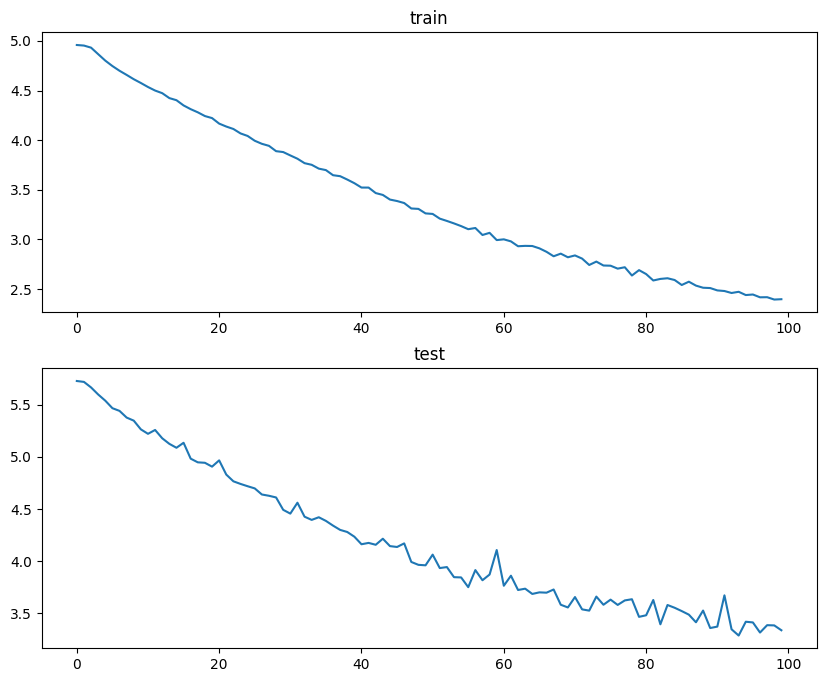

In [34]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()